In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Real-World Data: Major Hospitals in Bengaluru
# Format: [Latitude, Longitude]
hospitals = np.array([
    [12.8960, 77.5980],  # Apollo Hospitals, Bannerghatta
    [12.9592, 77.6485],  # Manipal Hospital, HAL Airport Road
    [12.9860, 77.5938],  # Fortis Hospital, Cunningham Road
    [12.8123, 77.6836],  # Narayana Health City, Bommasandra
    [13.0405, 77.5933]   # Aster CMI, Hebbal
])

hospital_names = [
    "Apollo (Bannerghatta)",
    "Manipal (HAL)",
    "Fortis (Cunningham)",
    "Narayana (Bommasandra)",
    "Aster CMI (Hebbal)"
]

# Emergency Demand Weights (Simulated daily flight requirements)
# E.g., Narayana gets a weight of 2.5 because it's a massive health city.
weights = np.array([1.5, 1.2, 1.0, 2.5, 0.8])

print("Data loaded successfully.")

Data loaded successfully.


In [ ]:
def calculate_cost(hub, hospitals, weights):
    """Calculates the total weighted Euclidean distance (Cost Function J)."""
    distances = np.sqrt(np.sum((hospitals - hub)**2, axis=1))
    return np.sum(weights * distances)

def calculate_gradient(hub, hospitals, weights):
    """Computes the partial derivatives with respect to X (Lat) and Y (Lon)."""
    # Epsilon prevents division by zero if the hub lands exactly on a hospital
    epsilon = 1e-8
    distances = np.sqrt(np.sum((hospitals - hub)**2, axis=1)) + epsilon

    # Gradient formulas derived using the chain rule
    dx = np.sum(weights * (hub[0] - hospitals[:, 0]) / distances)
    dy = np.sum(weights * (hub[1] - hospitals[:, 1]) / distances)

    return np.array([dx, dy])

print("Math functions compiled.")

Math functions compiled.


In [ ]:
def gradient_descent(hospitals, weights, learning_rate, iterations):
    # Initial guess: Start at the unweighted geographic center
    current_hub = np.mean(hospitals, axis=0)

    history = [current_hub.copy()]
    cost_history = [calculate_cost(current_hub, hospitals, weights)]

    for i in range(iterations):
        grad = calculate_gradient(current_hub, hospitals, weights)

        current_hub = current_hub - (learning_rate * grad)

        history.append(current_hub.copy())
        cost_history.append(calculate_cost(current_hub, hospitals, weights))

    return current_hub, np.array(history), cost_history

print("Optimizer ready.")

Optimizer ready.


In [ ]:
# HYPERPARAMETERS
learning_rate = 0.005  # Lowered significantly for GPS coordinate scale
iterations = 100       # Increased iterations for a smooth curve

optimal_hub, hub_history, cost_history = gradient_descent(
    hospitals, weights, learning_rate, iterations
)

print("--- OPTIMIZATION RESULTS ---")
print(f"Initial Starting Coordinates: {hub_history[0]}")
print(f"Optimal Hub Coordinates (GPS): {optimal_hub}")
print(f"Initial Total Cost (Distance): {cost_history[0]:.4f}")
print(f"Optimized Total Cost (Distance): {cost_history[-1]:.4f}")

--- OPTIMIZATION RESULTS ---
Initial Starting Coordinates: [12.9388  77.62344]
Optimal Hub Coordinates (GPS): [12.90855174 77.62304411]
Initial Total Cost (Distance): 0.6042
Optimized Total Cost (Distance): 0.5853


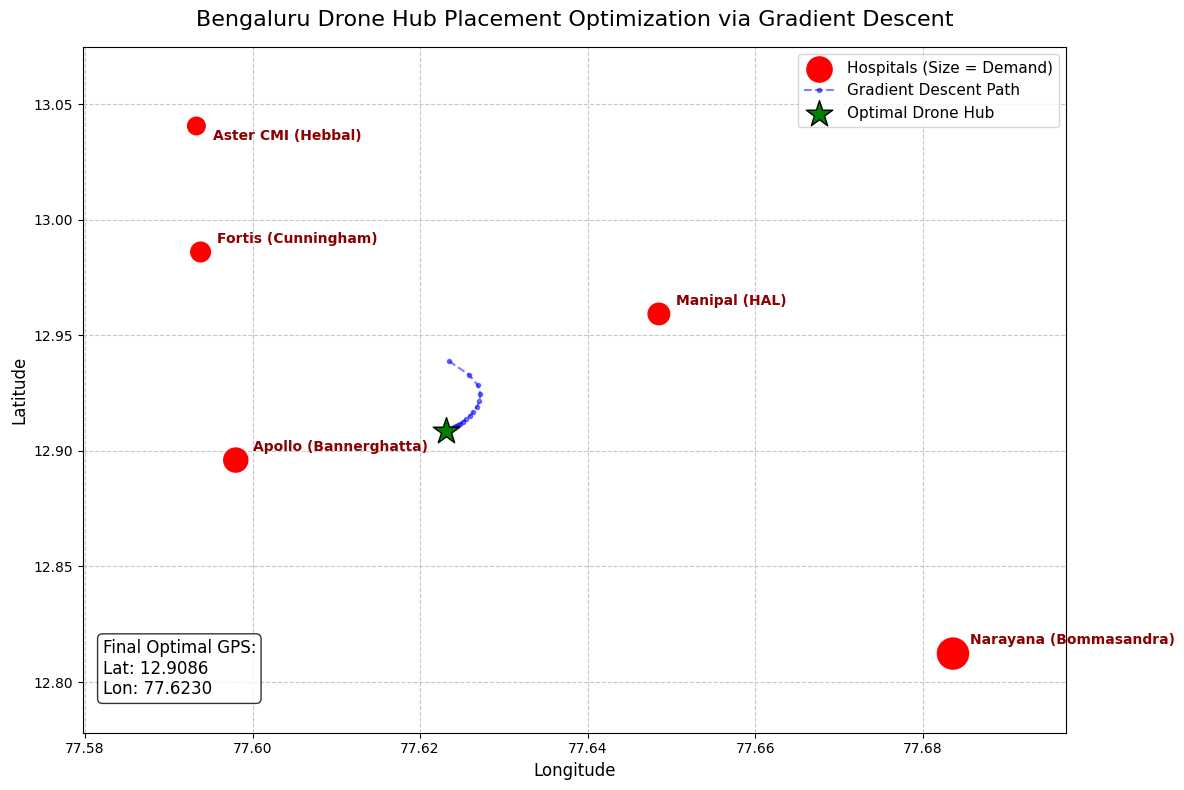

In [ ]:
plt.figure(figsize=(12, 8))

# Add a margin so points and text don't hit the edges
plt.margins(0.15)

# 1. Plot the Hospitals
scatter = plt.scatter(hospitals[:, 1], hospitals[:, 0],
                      color='red', s=weights*200,
                      label='Hospitals (Size = Demand)', zorder=5)

# Annotate real hospital names
for i, name in enumerate(hospital_names):
    # For Aster CMI, push the text down instead of up so it doesn't hit the roof
    if name == "Aster CMI (Hebbal)":
        plt.annotate(name, (hospitals[i, 1] + 0.002, hospitals[i, 0] - 0.006),
                     fontsize=10, fontweight='bold', color='darkred')
    else:
        plt.annotate(name, (hospitals[i, 1] + 0.002, hospitals[i, 0] + 0.004),
                     fontsize=10, fontweight='bold', color='darkred')

# 2. Plot the Gradient Descent Path
plt.plot(hub_history[:, 1], hub_history[:, 0],
         color='blue', marker='.', linestyle='dashed', alpha=0.5,
         label='Gradient Descent Path')

# 3. Plot the Final Hub Location
plt.scatter(optimal_hub[1], optimal_hub[0],
            color='green', marker='*', s=400, edgecolors='black',
            label='Optimal Drone Hub', zorder=6)

# Labels and formatting
plt.title('Bengaluru Drone Hub Placement Optimization via Gradient Descent', fontsize=16, pad=15)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Move legend to upper right to keep the top left clear
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Add a text box with the final GPS coordinates
textstr = f"Final Optimal GPS:\nLat: {optimal_hub[0]:.4f}\nLon: {optimal_hub[1]:.4f}"
plt.text(0.02, 0.05, textstr, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()